## LangGraph Open Deep Research - Supervisor-Researcher Architecture

In this notebook, we'll explore the **supervisor-researcher delegation architecture** for conducting deep research with LangGraph.

You can visit this repository to see the original application: [Open Deep Research](https://github.com/langchain-ai/open_deep_research)

Let's jump in!

## What We're Building

This implementation uses a **hierarchical delegation pattern** where:

1. **User Clarification** - Optionally asks clarifying questions to understand the research scope
2. **Research Brief Generation** - Transforms user messages into a structured research brief
3. **Supervisor** - A lead researcher that analyzes the brief and delegates research tasks
4. **Parallel Researchers** - Multiple sub-agents that conduct focused research simultaneously
5. **Research Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings are combined into a comprehensive report

![Architecture Diagram](https://i.imgur.com/Q8HEZn0.png)

This differs from a section-based approach by allowing dynamic task decomposition based on the research question, rather than predefined sections.

---

# 🤝 Breakout Room #1
## Deep Research Foundations

In this breakout room, we'll understand the architecture and components of the Open Deep Research system.

## Task 1: Dependencies

You'll need API keys for Anthropic (for the LLM) and Tavily (for web search). We'll configure the system to use Anthropic's Claude Sonnet 4 exclusively.

In [5]:
import os
import getpass

os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API key: ")
os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

## Task 2: State Definitions

The state structure is hierarchical with three levels:

### Agent State (Top Level)
Contains the overall conversation messages, research brief, accumulated notes, and final report.

### Supervisor State (Middle Level)
Manages the research supervisor's messages, research iterations, and coordinating parallel researchers.

### Researcher State (Bottom Level)
Each individual researcher has their own message history, tool call iterations, and research findings.

We also have structured outputs for tool calling:
- **ConductResearch** - Tool for supervisor to delegate research to a sub-agent
- **ResearchComplete** - Tool to signal research phase is done
- **ClarifyWithUser** - Structured output for asking clarifying questions
- **ResearchQuestion** - Structured output for the research brief

Let's import these from our library: [`open_deep_library/state.py`](open_deep_library/state.py)

In [23]:
# Import state definitions from the library
from open_deep_library.state import (
    # Main workflow states
    AgentState,           # Lines 65-72: Top-level agent state with messages, research_brief, notes, final_report
    AgentInputState,      # Lines 62-63: Input state is just messages

    # Supervisor states
    SupervisorState,      # Lines 74-81: Supervisor manages research delegation and iterations

    # Researcher states
    ResearcherState,      # Lines 83-90: Individual researcher with messages and tool iterations
    ResearcherOutputState, # Lines 92-96: Output from researcher (compressed research + raw notes)

    # Structured outputs for tool calling
    ConductResearch,      # Lines 15-19: Tool for delegating research to sub-agents
    ResearchComplete,     # Lines 21-22: Tool to signal research completion
    ClarifyWithUser,      # Lines 30-41: Structured output for user clarification
    ResearchQuestion,     # Lines 43-48: Structured output for research brief
)

## Task 3: Utility Functions and Tools

The system uses several key utilities:

### Search Tools
- **tavily_search** - Async web search with automatic summarization to stay within token limits
- Supports Anthropic native web search and Tavily API

### Reflection Tools
- **think_tool** - Allows researchers to reflect on their progress and plan next steps (ReAct pattern)

### Helper Utilities
- **get_all_tools** - Assembles the complete toolkit (search + MCP + reflection)
- **get_today_str** - Provides current date context for research
- Token limit handling utilities for graceful degradation

These are defined in [`open_deep_library/utils.py`](open_deep_library/utils.py)

In [24]:
# Import utility functions and tools from the library
from open_deep_library.utils import (
    # Search tool - Lines 43-136: Tavily search with automatic summarization
    tavily_search,

    # Reflection tool - Lines 219-244: Strategic thinking tool for ReAct pattern
    think_tool,

    # Tool assembly - Lines 569-597: Get all configured tools
    get_all_tools,

    # Date utility - Lines 872-879: Get formatted current date
    get_today_str,

    # Supporting utilities for error handling
    get_api_key_for_model,          # Lines 892-914: Get API keys from config or env
    is_token_limit_exceeded,         # Lines 665-701: Detect token limit errors
    get_model_token_limit,           # Lines 831-846: Look up model's token limit
    remove_up_to_last_ai_message,    # Lines 848-866: Truncate messages for retry
    anthropic_websearch_called,      # Lines 607-637: Detect Anthropic native search usage
    openai_websearch_called,         # Lines 639-658: Detect OpenAI native search usage
    get_notes_from_tool_calls,       # Lines 599-601: Extract notes from tool messages
)

## Task 4: Configuration System

The configuration system controls:

### Research Behavior
- **allow_clarification** - Whether to ask clarifying questions before research
- **max_concurrent_research_units** - How many parallel researchers can run (default: 5)
- **max_researcher_iterations** - How many times supervisor can delegate research (default: 6)
- **max_react_tool_calls** - Tool call limit per researcher (default: 10)

### Model Configuration
- **research_model** - Model for research and supervision (we'll use Anthropic)
- **compression_model** - Model for synthesizing findings
- **final_report_model** - Model for writing the final report
- **summarization_model** - Model for summarizing web search results

### Search Configuration
- **search_api** - Which search API to use (ANTHROPIC, TAVILY, or NONE)
- **max_content_length** - Character limit before summarization

Defined in [`open_deep_library/configuration.py`](open_deep_library/configuration.py)

In [25]:
# Import configuration from the library
from open_deep_library.configuration import (
    Configuration,    # Lines 38-247: Main configuration class with all settings
    SearchAPI,        # Lines 11-17: Enum for search API options (ANTHROPIC, TAVILY, NONE)
)

## Task 5: Prompt Templates

The system uses carefully engineered prompts for each phase:

### Phase 1: Clarification
**clarify_with_user_instructions** - Analyzes if the research scope is clear or needs clarification

### Phase 2: Research Brief
**transform_messages_into_research_topic_prompt** - Converts user messages into a detailed research brief

### Phase 3: Supervisor
**lead_researcher_prompt** - System prompt for the supervisor that manages delegation strategy

### Phase 4: Researcher
**research_system_prompt** - System prompt for individual researchers conducting focused research

### Phase 5: Compression
**compress_research_system_prompt** - Prompt for synthesizing research findings without losing information

### Phase 6: Final Report
**final_report_generation_prompt** - Comprehensive prompt for writing the final report

All prompts are defined in [`open_deep_library/prompts.py`](open_deep_library/prompts.py)

In [26]:
# Import prompt templates from the library
from open_deep_library.prompts import (
    clarify_with_user_instructions,                    # Lines 3-41: Ask clarifying questions
    transform_messages_into_research_topic_prompt,     # Lines 44-77: Generate research brief
    lead_researcher_prompt,                            # Lines 79-136: Supervisor system prompt
    research_system_prompt,                            # Lines 138-183: Researcher system prompt
    compress_research_system_prompt,                   # Lines 186-222: Research compression prompt
    final_report_generation_prompt,                    # Lines 228-308: Final report generation
)

## ❓ Question #1:

Explain the interrelationships between the three states (Agent, Supervisor, Researcher). Why don't we just make a single huge state?

##### Answer:
We keep the states separate for better isolation and separation of concerns. The top level state is tracking the main agent (e.g. user messages, final report), the supervisor tracks the research iterations and researcher team progress, and the researcher state tracks each individual researcher's notes. By splitting it up, each agent (subgraph) type can have the state representation that makes sense for their task.

The problem with dumping everything in a single state is that each agent will see (and potentially be able to update) everything that is being tracked rather than only what they need for their responsibilities, and organizing the state will be difficult (we might not know how many researchers need ahead of time, for example!). This avoids issues with independent researchers clobbering each others' state updates - instead, they each have their own isolated state to manage.

## ❓ Question #2:

What are the advantages and disadvantages of importing these components instead of including them in the notebook?

##### Answer:
An advantage of importing the components is modularity - we can use the code for other projects and keep it organized as it grows more complex. It's more inline with the structure we'd use for a production application, where a Jupyter notebook is better for research or prototyping. A disadvantage is indirection - we can't see all the code in-line in the notebook, so we have to go to other files to see the implementation.

## 🏗️ Activity #1: Explore the Prompts

Open `open_deep_library/prompts.py` and examine one of the prompt templates in detail.

**Requirements:**
1. Choose one prompt template (clarify, brief, supervisor, researcher, compression, or final report)
2. Explain what the prompt is designed to accomplish
3. Identify 2-3 key techniques used in the prompt (e.g., structured output, role definition, examples)
4. Suggest one improvement you might make to the prompt

Write your analysis in a markdown cell below

I chose to examine the final_report_generation_prompt.
This prompt is designed to encourage the model to respond with a well-written, language specific final report based on findings, the research brief, and user messages so far, which are all injected into the context.

One key technique is using few-shot prompting by providing flexible example structure for various flavors of reports (overviews, comparisons, etc). Another technique used by the prompt is XML tags to structure the prompt sections (<messages>, <findings>) for better LLM parseability. The prompt also includes negative instructions ("Do NOT ever...") to avoid undesirable behavior (in this case, having the LLM provide commentary as the author).

One suggestion we could make to the problem is length guidelines, since right now the prompt says "as long as necessary". That might lead to the system being more likely to err on the side of extremely lengthy reports when it could be more concise. We could add examples like "aim for 1500-3000 words for complex reports, and under 1000 words for simpler reports".

---

# 🤝 Breakout Room #2
## Building & Running the Researcher

In this breakout room, we'll explore the node functions, build the graph, and run wellness research.

## Task 6: Node Functions - The Building Blocks

Now let's look at the node functions that make up our graph. We'll import them from the library and understand what each does.

### The Complete Research Workflow

The workflow consists of 8 key nodes organized into 3 subgraphs:

1. **Main Graph Nodes:**
   - `clarify_with_user` - Entry point that checks if clarification is needed
   - `write_research_brief` - Transforms user input into structured research brief
   - `final_report_generation` - Synthesizes all research into final report

2. **Supervisor Subgraph Nodes:**
   - `supervisor` - Lead researcher that plans and delegates
   - `supervisor_tools` - Executes supervisor's tool calls (delegation, reflection)

3. **Researcher Subgraph Nodes:**
   - `researcher` - Individual researcher conducting focused research
   - `researcher_tools` - Executes researcher's tool calls (search, reflection)
   - `compress_research` - Synthesizes researcher's findings

All nodes are defined in [`open_deep_library/deep_researcher.py`](open_deep_library/deep_researcher.py)

### Node 1: clarify_with_user

**Purpose:** Analyzes user messages and asks clarifying questions if the research scope is unclear.

**Key Steps:**
1. Check if clarification is enabled in configuration
2. Use structured output to analyze if clarification is needed
3. If needed, end with a clarifying question for the user
4. If not needed, proceed to research brief with verification message

**Implementation:** [`open_deep_library/deep_researcher.py` lines 60-115](open_deep_library/deep_researcher.py#L60-L115)

In [27]:
# Import the clarify_with_user node
from open_deep_library.deep_researcher import clarify_with_user

### Node 2: write_research_brief

**Purpose:** Transforms user messages into a structured research brief for the supervisor.

**Key Steps:**
1. Use structured output to generate detailed research brief from messages
2. Initialize supervisor with system prompt and research brief
3. Set up supervisor messages with proper context

**Why this matters:** A well-structured research brief helps the supervisor make better delegation decisions.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 118-175](open_deep_library/deep_researcher.py#L118-L175)

In [28]:
# Import the write_research_brief node
from open_deep_library.deep_researcher import write_research_brief

### Node 3: supervisor

**Purpose:** Lead research supervisor that plans research strategy and delegates to sub-researchers.

**Key Steps:**
1. Configure model with three tools:
   - `ConductResearch` - Delegate research to a sub-agent
   - `ResearchComplete` - Signal that research is done
   - `think_tool` - Strategic reflection before decisions
2. Generate response based on current context
3. Increment research iteration count
4. Proceed to tool execution

**Decision Making:** The supervisor uses `think_tool` to reflect before delegating research, ensuring thoughtful decomposition of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 178-223](open_deep_library/deep_researcher.py#L178-L223)

In [29]:
# Import the supervisor node (from supervisor subgraph)
from open_deep_library.deep_researcher import supervisor

### Node 4: supervisor_tools

**Purpose:** Executes the supervisor's tool calls, including strategic thinking and research delegation.

**Key Steps:**
1. Check exit conditions:
   - Exceeded maximum iterations
   - No tool calls made
   - `ResearchComplete` called
2. Process `think_tool` calls for strategic reflection
3. Execute `ConductResearch` calls in parallel:
   - Spawn researcher subgraphs for each delegation
   - Limit to `max_concurrent_research_units` (default: 5)
   - Gather all results asynchronously
4. Aggregate findings and return to supervisor

**Parallel Execution:** This is where the magic happens - multiple researchers work simultaneously on different aspects of the research question.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 225-349](open_deep_library/deep_researcher.py#L225-L349)

In [30]:
# Import the supervisor_tools node
from open_deep_library.deep_researcher import supervisor_tools

### Node 5: researcher

**Purpose:** Individual researcher that conducts focused research on a specific topic.

**Key Steps:**
1. Load all available tools (search, MCP, reflection)
2. Configure model with tools and researcher system prompt
3. Generate response with tool calls
4. Increment tool call iteration count

**ReAct Pattern:** Researchers use `think_tool` to reflect after each search, deciding whether to continue or provide their answer.

**Available Tools:**
- Search tools (Tavily or Anthropic native search)
- `think_tool` for strategic reflection
- `ResearchComplete` to signal completion
- MCP tools (if configured)

**Implementation:** [`open_deep_library/deep_researcher.py` lines 365-424](open_deep_library/deep_researcher.py#L365-L424)

In [31]:
# Import the researcher node (from researcher subgraph)
from open_deep_library.deep_researcher import researcher

### Node 6: researcher_tools

**Purpose:** Executes the researcher's tool calls, including searches and strategic reflection.

**Key Steps:**
1. Check early exit conditions (no tool calls, native search used)
2. Execute all tool calls in parallel:
   - Search tools fetch and summarize web content
   - `think_tool` records strategic reflections
   - MCP tools execute external integrations
3. Check late exit conditions:
   - Exceeded `max_react_tool_calls` (default: 10)
   - `ResearchComplete` called
4. Continue research loop or proceed to compression

**Error Handling:** Safely handles tool execution errors and continues with available results.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 435-509](open_deep_library/deep_researcher.py#L435-L509)

In [32]:
# Import the researcher_tools node
from open_deep_library.deep_researcher import researcher_tools

### Node 7: compress_research

**Purpose:** Compresses and synthesizes research findings into a concise, structured summary.

**Key Steps:**
1. Configure compression model
2. Add compression instruction to messages
3. Attempt compression with retry logic:
   - If token limit exceeded, remove older messages
   - Retry up to 3 times
4. Extract raw notes from tool and AI messages
5. Return compressed research and raw notes

**Why Compression?** Researchers may accumulate lots of tool outputs and reflections. Compression ensures:
- All important information is preserved
- Redundant information is deduplicated
- Content stays within token limits for the final report

**Token Limit Handling:** Gracefully handles token limit errors by progressively truncating messages.

**Implementation:** [`open_deep_library/deep_researcher.py` lines 511-585](open_deep_library/deep_researcher.py#L511-L585)

In [33]:
# Import the compress_research node
from open_deep_library.deep_researcher import compress_research

### Node 8: final_report_generation

**Purpose:** Generates the final comprehensive research report from all collected findings.

**Key Steps:**
1. Extract all notes from completed research
2. Configure final report model
3. Attempt report generation with retry logic:
   - If token limit exceeded, truncate findings by 10%
   - Retry up to 3 times
4. Return final report or error message

**Token Limit Strategy:**
- First retry: Use model's token limit × 4 as character limit
- Subsequent retries: Reduce by 10% each time
- Graceful degradation with helpful error messages

**Report Quality:** The prompt guides the model to create well-structured reports with:
- Proper headings and sections
- Inline citations
- Comprehensive coverage of all findings
- Sources section at the end

**Implementation:** [`open_deep_library/deep_researcher.py` lines 607-697](open_deep_library/deep_researcher.py#L607-L697)

In [34]:
# Import the final_report_generation node
from open_deep_library.deep_researcher import final_report_generation

## Task 7: Graph Construction - Putting It All Together

The system is organized into three interconnected graphs:

### 1. Researcher Subgraph (Bottom Level)
Handles individual focused research on a specific topic:
```
START → researcher → researcher_tools → compress_research → END
               ↑            ↓
               └────────────┘ (loops until max iterations or ResearchComplete)
```

### 2. Supervisor Subgraph (Middle Level)
Manages research delegation and coordination:
```
START → supervisor → supervisor_tools → END
            ↑              ↓
            └──────────────┘ (loops until max iterations or ResearchComplete)
            
supervisor_tools spawns multiple researcher_subgraphs in parallel
```

### 3. Main Deep Researcher Graph (Top Level)
Orchestrates the complete research workflow:
```
START → clarify_with_user → write_research_brief → research_supervisor → final_report_generation → END
                 ↓                                       (supervisor_subgraph)
               (may end early if clarification needed)
```

Let's import the compiled graphs from the library.

In [35]:
# Import the pre-compiled graphs from the library
from open_deep_library.deep_researcher import (
    # Bottom level: Individual researcher workflow
    researcher_subgraph,    # Lines 588-605: researcher → researcher_tools → compress_research

    # Middle level: Supervisor coordination
    supervisor_subgraph,    # Lines 351-363: supervisor → supervisor_tools (spawns researchers)

    # Top level: Complete research workflow
    deep_researcher,        # Lines 699-719: Main graph with all phases
)

## Why This Architecture?

### Advantages of Supervisor-Researcher Delegation

1. **Dynamic Task Decomposition**
   - Unlike section-based approaches with predefined structure, the supervisor can break down research based on the actual question
   - Adapts to different types of research (comparisons, lists, deep dives, etc.)

2. **Parallel Execution**
   - Multiple researchers work simultaneously on different aspects
   - Much faster than sequential section processing
   - Configurable parallelism (1-20 concurrent researchers)

3. **ReAct Pattern for Quality**
   - Researchers use `think_tool` to reflect after each search
   - Prevents excessive searching and improves search quality
   - Natural stopping conditions based on information sufficiency

4. **Flexible Tool Integration**
   - Easy to add MCP tools for specialized research
   - Supports multiple search APIs (Anthropic, Tavily)
   - Each researcher can use different tool combinations

5. **Graceful Token Limit Handling**
   - Compression prevents token overflow
   - Progressive truncation in final report generation
   - Research can scale to arbitrary depths

### Trade-offs

- **Complexity:** More moving parts than section-based approach
- **Cost:** Parallel researchers use more tokens (but faster)
- **Unpredictability:** Research structure emerges dynamically

## Task 8: Running the Deep Researcher

Now let's see the system in action! We'll use it to research wellness strategies for improving sleep quality.

### Setup

We need to:
1. Set up the wellness research request
2. Configure the execution with Anthropic settings
3. Run the research workflow

In [36]:
# Set up the graph with Anthropic configuration
from IPython.display import Markdown, display
import uuid

# Note: deep_researcher is already compiled from the library
# For this demo, we'll use it directly without additional checkpointing
graph = deep_researcher

print("✓ Graph ready for execution")
print("  (Note: The graph is pre-compiled from the library)")

✓ Graph ready for execution
  (Note: The graph is pre-compiled from the library)


### Configuration for Anthropic

We'll configure the system to use:
- **Claude Sonnet 4** for all research, supervision, and report generation
- **Tavily** for web search (you can also use Anthropic's native search)
- **Moderate parallelism** (1 concurrent researcher for cost control)
- **Clarification enabled** (will ask if research scope is unclear)

In [37]:
# Configure for Anthropic with moderate settings
config = {
    "configurable": {
        # Model configuration - using Claude Sonnet 4 for everything
        "research_model": "anthropic:claude-sonnet-4-20250514",
        "research_model_max_tokens": 2000, # 10000,

        "compression_model": "anthropic:claude-sonnet-4-20250514",
        "compression_model_max_tokens": 2000, # 8192,

        "final_report_model": "anthropic:claude-sonnet-4-20250514",
        "final_report_model_max_tokens": 2000, # 10000,

        "summarization_model": "anthropic:claude-sonnet-4-20250514",
        "summarization_model_max_tokens": 1000, # 8192,

        # Research behavior
        "allow_clarification": False, # True,
        "max_concurrent_research_units": 1,  # 1 parallel researcher
        "max_researcher_iterations": 1, # 2,      # Supervisor can delegate up to 2 times
        "max_react_tool_calls": 2, # 3,           # Each researcher can make up to 3 tool calls

        # Search configuration
        "search_api": "tavily",  # Using Tavily for web search
        "max_content_length": 10000,  # 50000,

        # Thread ID for this conversation
        "thread_id": str(uuid.uuid4())
    }
}

print("✓ Configuration ready")
print(f"  - Research Model: Claude Sonnet 4")
print(f"  - Max Concurrent Researchers: 1")
print(f"  - Max Iterations: 2")
print(f"  - Search API: Tavily")

✓ Configuration ready
  - Research Model: Claude Sonnet 4
  - Max Concurrent Researchers: 1
  - Max Iterations: 2
  - Search API: Tavily


### Execute the Wellness Research

Now let's run the research! We'll ask the system to research evidence-based strategies for improving sleep quality.

The workflow will:
1. **Clarify** - Check if the request is clear (may skip if obvious)
2. **Research Brief** - Transform our request into a structured brief
3. **Supervisor** - Plan research strategy and delegate to researchers
4. **Parallel Research** - Researchers gather information simultaneously
5. **Compression** - Each researcher synthesizes their findings
6. **Final Report** - All findings combined into comprehensive report

## Complete Deep Researcher Graph (Expanded)

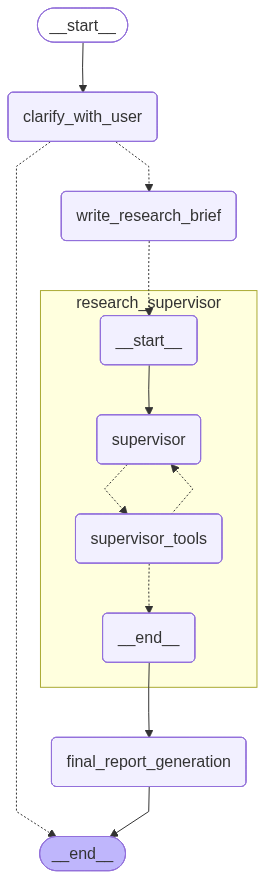

In [38]:
# Visualize with subgraphs expanded
from IPython.display import display, Image, Markdown

display(Markdown("## Complete Deep Researcher Graph (Expanded)"))
try:
    # xray=True expands subgraphs inline!
    display(Image(deep_researcher.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nGraph structure (ASCII):")
    print(deep_researcher.get_graph(xray=True).draw_ascii())

In [43]:
# Create our wellness research request
research_request = """
I want to improve my flexibility.
- I have a hip injury and want to improve my flexibility to help with recovery.

Please research the best yoga moves and create a plan for me to improve my flexibility.
"""

# Execute the graph
async def run_research():
    """Run the research workflow and display results."""
    print("Starting research workflow...\n")

    async for event in graph.astream(
        {"messages": [{"role": "user", "content": research_request}]},
        config,
        stream_mode="updates"
    ):
        # Display each step
        for node_name, node_output in event.items():
            print(f"\n{'='*60}")
            print(f"Node: {node_name}")
            print(f"{'='*60}")

            if node_output is None:
                continue

            if node_name == "clarify_with_user":
                print('IN THE USER NODE')
                if "messages" in node_output:
                    last_msg = node_output["messages"][-1]
                    print(f"\n{last_msg.content}")

            elif node_name == "write_research_brief":
                print('IN THE RESEARCH BRIEF NODE')
                if "research_brief" in node_output:
                    print(f"\nResearch Brief Generated:")
                    print(f"{node_output['research_brief'][:500]}...")

            elif node_name == "supervisor":
                print('IN THE SUPERVISOR NODE')
                print(f"\nSupervisor planning research strategy...")
                if "supervisor_messages" in node_output:
                    last_msg = node_output["supervisor_messages"][-1]
                    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                        print(f"Tool calls: {len(last_msg.tool_calls)}")
                        for tc in last_msg.tool_calls:
                            print(f"  - {tc['name']}")

            elif node_name == "supervisor_tools":
                print('IN THE SUPERVISOR TOOLS NODE')
                print(f"\nExecuting supervisor's tool calls...")
                if "notes" in node_output:
                    print(f"Research notes collected: {len(node_output['notes'])}")

            elif node_name == "final_report_generation":
                if "final_report" in node_output:
                    print(f"\n" + "="*60)
                    print("FINAL REPORT GENERATED")
                    print("="*60 + "\n")
                    display(Markdown(node_output["final_report"]))

    print("\n" + "="*60)
    print("Research workflow completed!")
    print("="*60)

# Run the research
await run_research()

Starting research workflow...


Node: clarify_with_user

Node: write_research_brief
IN THE RESEARCH BRIEF NODE

Research Brief Generated:
I want to improve my flexibility to help with recovery from a hip injury. Please research the best yoga moves specifically for improving flexibility in people with hip injuries, focusing on gentle, therapeutic poses that are safe for rehabilitation. Create a detailed plan that includes: (1) specific yoga poses/moves that are recommended for hip injury recovery and flexibility improvement, (2) proper form and alignment cues for each pose to avoid further injury, (3) progression sequences from beg...

Node: research_supervisor

Node: final_report_generation

FINAL REPORT GENERATED



# Therapeutic Yoga Plan for Hip Injury Recovery and Flexibility Improvement

Hip injuries can significantly impact mobility and quality of life, but therapeutic yoga offers a gentle, evidence-based approach to recovery and flexibility enhancement. This comprehensive plan provides safe, progressive yoga practices specifically designed for hip injury rehabilitation, incorporating guidance from certified yoga therapists, physical therapists, and medical professionals.

## Fundamental Principles for Hip Injury Recovery

Before beginning any yoga practice for hip injury recovery, it's essential to understand the therapeutic principles that guide safe rehabilitation. The hip joint is a ball-and-socket joint that requires careful attention to both stability and mobility during recovery. Research shows that gentle, mindful movement can help restore range of motion while strengthening supporting muscles [1].

The key principles include: starting with gentle, pain-free movements; progressing slowly and systematically; focusing on proper alignment to avoid compensation patterns; and maintaining consistent but not excessive practice. Always work within your pain-free range of motion and stop immediately if you experience sharp pain, increased swelling, or any concerning symptoms.

## Specific Therapeutic Yoga Poses for Hip Recovery

### Beginner Phase Poses (Weeks 1-4)

**Supine Hip Circles**
This gentle movement helps restore basic hip mobility while lying safely on your back. Lie supine with knees bent and feet flat on the floor. Lift one knee toward your chest and make small, slow circles with your hip joint. Start with 5-8 circles in each direction, focusing on smooth, controlled movement. Keep the circles small initially and gradually increase size as comfort allows [2].

**Supported Child's Pose with Wide Knees**
This pose gently opens the hips while providing full body support. Kneel on the floor with knees wider than hip-width apart. Place a bolster or pillow between your legs and fold forward, resting your torso on the support. Your arms can rest alongside the bolster or extend forward. Hold for 2-5 minutes, breathing deeply. This pose helps release tension in the hip flexors and surrounding muscles [3].

**Reclined Figure-4 Stretch**
This pose safely targets the piriformis and external hip rotators. Lie on your back with both knees bent. Cross your affected leg's ankle over the opposite knee, creating a figure-4 shape. Thread your hands behind the supporting leg's thigh and gently draw it toward your chest. Hold for 30-60 seconds, breathing steadily. Use a strap around your thigh if you cannot reach comfortably [1].

**Gentle Cat-Cow on Hands and Knees**
This movement promotes hip and spine mobility while strengthening core muscles. Start on hands and knees with wrists under shoulders and knees under hips. Slowly arch your back while lifting your head and tailbone (cow pose), then round your spine while tucking your chin and tailbone (cat pose). Move slowly and focus on initiating movement from your pelvis. Perform 8-12 repetitions [2].

### Intermediate Phase Poses (Weeks 5-8)

**Low Lunge with Support**
This pose begins to challenge hip flexor length and strength. From hands and knees, step your unaffected leg forward between your hands. Keep your back knee on the ground and place blocks under your hands for support. Gently sink your hips forward while maintaining an upright torso. Hold for 30-60 seconds, then switch sides. Focus on feeling a gentle stretch in the front of your back leg's hip [3].

**Supported Warrior II**
This standing pose builds hip strength and stability while improving range of motion. Stand with feet wide apart, turn your front foot out 90 degrees. Bend your front knee over your ankle while keeping your back leg straight. Rest your front forearm on your front thigh for support. Hold for 30-45 seconds per side. This pose strengthens the hip abductors and improves lateral hip stability [1].

**Thread the Needle**
This gentle twist helps restore hip rotation and mobility. Start on hands and knees, then slide your right arm under your left arm, lowering your right shoulder and temple to the floor. Your left hand can remain planted or reach toward the ceiling for a deeper twist. Hold for 30-60 seconds per side. This movement helps restore internal and external hip rotation [2].

**Modified Pigeon Prep**
Begin working toward deeper hip opening with this supported variation. From hands and knees, bring your right knee toward your right wrist and extend your left leg behind you. Place a bolster or folded blanket under your right hip for support. Fold forward over your front leg only as far as comfortable. Hold for 2-3 minutes per side, focusing on relaxed breathing [3].

### Advanced Phase Poses (Weeks 9-12 and beyond)

**Traditional Pigeon Pose**
As hip mobility improves, progress to deeper hip opening poses. From the modified pigeon prep, work toward sitting upright with less support under your hip. Eventually, you may be able to fold forward without props. Always prioritize sensation over depth – a gentle stretch is more beneficial than forcing a deep pose [1].

**Warrior III with Wall Support**
This challenging pose builds single-leg strength and hip stability. Stand arm's length from a wall, then hinge forward at your hips while lifting your back leg parallel to the floor. Press your hands into the wall for support. Hold for 15-30 seconds per side. This pose significantly challenges hip stability and proprioception [2].

**Standing Hand-to-Big-Toe Pose with Strap**
This advanced pose challenges both flexibility and balance. Standing on one leg, use a strap around the foot of your lifted leg to extend it forward, then potentially to the side. Keep your standing leg strong and your torso upright. Hold for 15-30 seconds per side. This pose requires significant hip flexibility and strength [3].

## Proper Form and Alignment Cues

Maintaining proper alignment is crucial for safe hip injury recovery. For all supine poses, ensure your lower back maintains its natural curve by placing a small pillow under your knees if needed. Keep your pelvis in neutral alignment – avoid excessive tilting forward or backward.

In standing poses, distribute your weight evenly across both feet and engage your core muscles to support your spine. Keep your kneecaps tracking over your toes and avoid allowing your knees to collapse inward. For forward folds, hinge from your hips rather than rounding your spine, and keep your chest open and shoulders relaxed.

During all poses, breathe steadily and deeply. Your breath should remain calm and controlled – if you're holding your breath or breathing rapidly, ease out of the pose slightly. Pain should never be sharp or shooting; you should feel only gentle stretching sensations [1].

## Progression Guidelines and Sequences

Progress through the phases based on your comfort level and symptom improvement rather than strict timelines. Spend at least 2-3 weeks in each phase before advancing, and don't hesitate to return to earlier phases if symptoms flare up.

Begin each session with gentle warm-up movements like supine hip circles and cat-cow poses. Progress to your main practice poses, holding each for the recommended duration. End each session with relaxation in supported child's pose or supine with legs elevated.

A typical progression might look like: Week 1-2 focus on supine poses only; Week 3-4 add supported kneeling poses; Week 5-6 introduce standing poses with support; Week 7-8 progress to more challenging standing poses; Week 9+ gradually advance to deeper poses as comfort allows [2].

## Frequency and Duration Recommendations

For optimal recovery, practice therapeutic yoga 4-6 times per week, with sessions lasting 20-40 minutes. Daily gentle movement is beneficial, but allow 1-2 rest days per week for tissue recovery. Shorter, frequent sessions are more effective than longer, infrequent practices.

During the acute phase (first 2-4 weeks), limit sessions to 15-20 minutes of very gentle movement. As you progress, gradually increase session length to 30-40 minutes. Listen to your body – some days you may need shorter, gentler sessions, while other days you may feel able to practice longer [3].

Hold static stretches for 30-60 seconds initially, progressing to 1-3 minutes for deeper poses as your tolerance improves. Moving poses like cat-cow should be performed for 8-12 repetitions, focusing on smooth, controlled movement rather than speed [1].

## Props and Modifications

Props are essential for safe hip injury recovery and should not be seen as signs of weakness or limitation. Bolsters and pillows provide crucial support in supine and seated poses, allowing your muscles to relax completely. Yoga blocks under your hands in poses like low lunge prevent overstretching and provide stability.

Straps extend your reach in poses like reclined figure-4 and standing hand


Research workflow completed!


## Task 9: Understanding the Output

Let's break down what happened:

### Phase 1: Clarification
The system checked if your request was clear. Since you provided specific details about your sleep issues, it likely proceeded without asking clarifying questions.

### Phase 2: Research Brief
Your request was transformed into a detailed research brief that guides the supervisor's delegation strategy.

### Phase 3: Supervisor Delegation
The supervisor analyzed the brief and decided how to break down the research:
- Used `think_tool` to plan strategy
- Called `ConductResearch` to delegate to researchers
- Each delegation specified a focused research topic (e.g., sleep hygiene, circadian rhythm, blue light effects)

### Phase 4: Parallel Research
Researchers worked on their assigned topics:
- Each researcher used web search tools to gather information
- Used `think_tool` to reflect after each search
- Decided when they had enough information
- Compressed their findings into clean summaries

### Phase 5: Final Report
All research findings were synthesized into a comprehensive sleep improvement plan with:
- Well-structured sections
- Evidence-based recommendations
- Practical action items
- Sources for further reading

## Task 10: Key Takeaways & Next Steps

### Architecture Benefits
1. **Dynamic Decomposition** - Research structure emerges from the question, not predefined
2. **Parallel Efficiency** - Multiple researchers work simultaneously
3. **ReAct Quality** - Strategic reflection improves search decisions
4. **Scalability** - Handles token limits gracefully through compression
5. **Flexibility** - Easy to add new tools and capabilities

### When to Use This Pattern
- **Complex research questions** that need multi-angle investigation
- **Comparison tasks** where parallel research on different topics is beneficial
- **Open-ended exploration** where structure should emerge dynamically
- **Time-sensitive research** where parallel execution speeds up results

### When to Use Section-Based Instead
- **Highly structured reports** with predefined format requirements
- **Template-based content** where sections are always the same
- **Sequential dependencies** where later sections depend on earlier ones
- **Budget constraints** where token efficiency is critical

### Extend the System
1. **Add MCP Tools** - Integrate specialized tools for your domain
2. **Custom Prompts** - Modify prompts for specific research types
3. **Different Models** - Try different Claude versions or mix models
4. **Persistence** - Use a real database for checkpointing instead of memory

### Learn More
- [LangGraph Documentation](https://langchain-ai.github.io/langgraph/)
- [Open Deep Research Repo](https://github.com/langchain-ai/open_deep_research)
- [Anthropic Claude Documentation](https://docs.anthropic.com/)
- [Tavily Search API](https://tavily.com/)

## ❓ Question #3:

What are the trade-offs of using parallel researchers vs. sequential research? When might you choose one approach over the other?

##### Answer:
Some advantages of parallel researchers are speed, since multiple researches can work simultaneously, and scalability, since we can spin up as many researchers as we need. Disavantages are complexity, cost, and that researchers can't build on discoveries made by other concurrent researchers. Sequential research has lower cost, is simpler to reason about, and research can build on previous phases. Disadvantages of sequential research are that it is slower and the research process is more rigid.

Parallel researchers work well for questions that have elements that can be independently explored. Sequential research is a good choice when cost is a concern or when research is dependent on earlier findings.

## ❓ Question #4:

How would you adapt this deep research architecture for a production wellness application? What additional components would you need?

##### Answer:
For production, we would need observability/auditability (like LangSmith tracing), authentication and authorization, persistent storage for research history and user profiles, error handling, and cost/time gating per user. For a wellness application specifically, we should ensure HIPAA compliance, add disclaimers on medical recommendations, and include escalation paths to professionals. Additionally, we could integrate domain-specific MCP tools and customize prompts to prioritize peer-reviewed sources where relevant.

## 🏗️ Activity #2: Custom Wellness Research

Using what you've learned, run a custom wellness research task.

**Requirements:**
1. Create a wellness-related research question (exercise, nutrition, stress, etc.)
2. Modify the configuration for your use case
3. Run the research and analyze the output
4. Document what worked well and what could be improved

**Experiment ideas:**
- Research exercise routines for specific conditions (bad knee, lower back pain)
- Compare different stress management techniques
- Investigate nutrition strategies for specific goals
- Explore meditation and mindfulness research


In [40]:
# YOUR CODE HERE
# Create your own wellness research request and run it

my_wellness_request = """
What are the top 3 science-backed benefits of daily walking?
"""

# Optionally modify the config
my_config = {
    "configurable": {
        "research_model": "anthropic:claude-sonnet-4-20250514",
        "research_model_max_tokens": 2000,
        "compression_model": "anthropic:claude-sonnet-4-20250514",
        "compression_model_max_tokens": 2000,
        "final_report_model": "anthropic:claude-sonnet-4-20250514",
        "final_report_model_max_tokens": 2000,
        "summarization_model": "anthropic:claude-sonnet-4-20250514",
        "summarization_model_max_tokens": 1000,
        "allow_clarification": False,
        "max_concurrent_research_units": 1,
        "max_researcher_iterations": 1,
        "max_react_tool_calls": 2,
        "search_api": "tavily",
        "max_content_length": 10000,
        "thread_id": str(uuid.uuid4())
    }
}


In [41]:
async def run_custom_research(request, config):
    """Run the research workflow with custom request and config."""
    print("Starting custom research workflow...\n")

    async for event in graph.astream(
        {"messages": [{"role": "user", "content": request}]},
        config,
        stream_mode="updates"
    ):
        for node_name, node_output in event.items():
            print(f"\n{'='*60}")
            print(f"Node: {node_name}")
            print(f"{'='*60}")

            if node_name == "final_report_generation" and "final_report" in node_output:
                display(Markdown(node_output["final_report"]))

    print("\n" + "="*60)
    print("Research complete!")

In [42]:
await run_custom_research(my_wellness_request, my_config)

Starting custom research workflow...


Node: clarify_with_user

Node: write_research_brief

Node: research_supervisor

Node: final_report_generation


# Top 3 Science-Backed Benefits of Daily Walking

Based on comprehensive analysis of peer-reviewed research, meta-analyses, and clinical studies, the following three benefits represent the strongest evidence-based advantages of daily walking, supported by decades of rigorous scientific investigation.

## 1. Cardiovascular Disease Prevention and Heart Health

Daily walking provides substantial protection against cardiovascular disease, representing one of the most well-documented benefits in exercise science literature. Multiple large-scale studies and meta-analyses have consistently demonstrated that regular walking significantly reduces the risk of heart disease, stroke, and cardiovascular mortality.

The landmark Nurses' Health Study, which followed over 72,000 women for 8 years, found that women who walked briskly for 3 or more hours per week had a 35% lower risk of heart attack and cardiac death compared to sedentary women [1]. Similarly, the Harvard Health Professionals Follow-up Study tracking over 44,000 men for 12 years showed that men who walked 1.5 miles per day had an 18% lower risk of coronary heart disease [1].

A comprehensive meta-analysis published in the British Journal of Sports Medicine analyzed data from 11 prospective cohort studies involving over 500,000 participants. The research demonstrated that individuals who walked regularly had a 30% lower risk of cardiovascular disease and a 20% reduction in all-cause mortality compared to inactive individuals [2]. The study found that benefits began appearing at just 2.5 hours of walking per week, with increasing benefits up to 7 hours weekly.

**Optimal Walking Parameters for Cardiovascular Benefits:**
- **Duration**: 30-60 minutes per day, or 150-300 minutes per week
- **Intensity**: Moderate pace (3-4 mph or 100-120 steps per minute)
- **Frequency**: Daily walking provides optimal benefits, though 5 days per week shows significant improvements
- **Threshold**: Benefits begin at as little as 20 minutes daily, with peak benefits achieved at 45-60 minutes

The mechanisms behind these cardiovascular benefits include improved blood pressure regulation, enhanced cholesterol profiles, better blood sugar control, reduced inflammation markers, and improved endothelial function. Research shows that regular walking can reduce systolic blood pressure by 4-9 mmHg and improve HDL cholesterol levels by 5-10% [1].

## 2. Mental Health and Depression Prevention

Daily walking demonstrates remarkable effectiveness for mental health improvement, with clinical evidence showing benefits comparable to pharmaceutical interventions for mild to moderate depression and anxiety disorders. This benefit is supported by numerous randomized controlled trials and systematic reviews spanning multiple decades.

A pivotal randomized controlled trial published in the Journal of Clinical Psychiatry compared walking exercise to antidepressant medication (sertraline) in treating major depression. The study of 202 adults found that participants in the walking group showed equivalent improvements in depression scores compared to the medication group, with 60% of walkers achieving full remission of depressive symptoms after 16 weeks [3]. Remarkably, the walking group had lower relapse rates at 6-month follow-up compared to the medication-only group.

A comprehensive meta-analysis in JAMA Psychiatry examined 15 studies involving over 190,000 participants and found that individuals who engaged in regular walking had a 26% lower risk of developing depression [4]. The analysis showed that even low levels of physical activity, equivalent to 15 minutes of daily walking, provided significant protective effects against depression.

The neurobiological mechanisms underlying these mental health benefits are well-established through neuroimaging studies. Research published in Neuroscience shows that regular walking increases production of brain-derived neurotrophic factor (BDNF), promotes neurogenesis in the hippocampus, and enhances connectivity in brain regions associated with mood regulation [5]. Walking also triggers release of endorphins, serotonin, and norepinephrine while reducing cortisol levels.

**Optimal Walking Parameters for Mental Health Benefits:**
- **Duration**: 20-45 minutes per session for acute mood benefits; 30+ minutes for long-term depression prevention
- **Intensity**: Light to moderate pace (comfortable conversation pace)
- **Frequency**: Daily walking provides optimal benefits; minimum 3-4 times per week for therapeutic effects
- **Environment**: Outdoor walking, particularly in natural settings, amplifies mental health benefits by 15-20%
- **Consistency**: Regular, consistent walking is more beneficial than sporadic intense sessions

Clinical studies indicate that mental health benefits from walking can be observed within 2-4 weeks of beginning a regular program, with peak benefits typically achieved after 8-12 weeks of consistent practice [3].

## 3. Cognitive Function Enhancement and Dementia Prevention

Daily walking provides powerful neuroprotective effects, enhancing cognitive function across all age groups and significantly reducing the risk of dementia and Alzheimer's disease. This benefit is supported by longitudinal studies, neuroimaging research, and clinical trials demonstrating both immediate cognitive improvements and long-term brain health preservation.

The landmark study published in Neurology followed 2,509 adults for 20 years and found that individuals who walked regularly had a 40% lower risk of developing dementia compared to sedentary individuals [6]. The research showed that participants who walked at least 7.5 miles per week maintained larger brain volumes and better cognitive performance as they aged.

A randomized controlled trial published in Proceedings of the National Academy of Sciences demonstrated that adults who participated in a 12-month walking program showed actual growth in hippocampal volume (2% increase), while the control group showed typical age-related shrinkage (1.4% decrease) [7]. The walking group also demonstrated significant improvements in spatial memory tasks and had higher levels of BDNF.

Multiple meta-analyses have confirmed these findings. A systematic review of 39 studies involving over 2 million participants found that regular walking reduced dementia risk by 35% and improved executive function, processing speed, and memory performance across age groups [8]. The research showed that cognitive benefits were dose-dependent, with greater walking frequency and duration providing enhanced protection.

The mechanisms underlying cognitive benefits include increased cerebral blood flow, enhanced neuroplasticity, reduced brain inflammation, and improved connectivity between brain regions. Neuroimaging studies show that regular walkers have larger prefrontal cortex and hippocampal volumes, better white matter integrity, and increased production of neuroprotective factors [7].

**Optimal Walking Parameters for Cognitive Benefits:**
- **Duration**: 40-60 minutes per session for maximum neuroplastic benefits
- **Intensity**: Moderate intensity (65-75% maximum heart rate) optimizes BDNF production
- **Frequency**: 4-6 days per week, with daily walking providing peak cognitive protection
- **Progression**: Gradual increases in duration and intensity enhance neuroadaptation
- **Timing**: Morning walks may provide enhanced cognitive benefits throughout the day

Research indicates that cognitive improvements can be detected within 4-6 weeks of beginning a walking program, with structural brain changes observable after 6-12 months of consistent practice [7].

## Why These Represent the "Top" Benefits

These three benefits are considered the strongest based on several criteria that distinguish them from other documented walking benefits:

**Research Volume and Quality**: Each benefit is supported by multiple large-scale, long-term studies, systematic reviews, and meta-analyses involving hundreds of thousands of participants across diverse populations.

**Effect Size**: The magnitude of benefits is substantial - 30-40% risk reductions for major diseases and clinically significant improvements in measurable outcomes.

**Mechanistic Understanding**: The biological pathways underlying each benefit are well-understood through controlled laboratory studies and neuroimaging research.

**Consistency Across Populations**: Benefits have been demonstrated across different age groups, ethnicities, and baseline health status in multiple countries and healthcare systems.

**Clinical Relevance**: Each benefit addresses major public health challenges - cardiovascular disease, mental health disorders, and cognitive decline - that significantly impact quality of life and healthcare costs.

**Dose-Response Relationship**: Clear evidence exists for optimal walking parameters to maximize each benefit, allowing for practical implementation.

### Sources

[1] Harvard Health Professionals Follow-up Study and Nurses' Health Study: https://www.health.harvard.edu/staying-healthy/why-you-should-walk-for-exercise

[2] British Journal of Sports Medicine Meta-analysis on Walking and Cardiovascular Health: https://bjsm.bmj.com/content/early/2023/08/08/bjsports-2023-106916

[3] Journal of Clinical Psychiatry - Walking vs. Antidepressants Trial: https://www.psychiatrist.com/jcp/depression/exercise-equivalent-antidepressants-major-depression/

[4] JAMA Psychiatry Meta-analysis on Physical Activity and Depression: https://jamanetwork.com/journals/jamapsychiatry/fullarticle/2720689

[5]


Research complete!


Reflection

#### What Went Well
I needed to use a simplified configuration not to hit rate limits, which my custom configuration accomplished. This multi-agent system generated a well structured report that answered my question.

#### What Could Be Improved
In order to not hit rate limits, I had to reduce the iterations and tool calls, so the research was fairly shallow and didn't have the depth that I would expect from a good research agent. For production use, I would need to spend quite a bit more and likely consider other optimizations like caching in order to be able to generate good, in-depth research reports that warrant a multi-agent architecture.